Logistic Regression
You are interviewing with Google’s data science team having the responsibility of predicting the Click Through Rate (CTR) of ads they place on multiple web properties. Your hiring manager keen on testing you out, suggests to download this dataset and asks you to code up a model that predicts the CTR based on Logistic Regression.

Task 1: Data Preprocessing
Preprocess the data you are given to your liking. This may include dropping some columns you wont use, addressing noisy or missing data etc.

Use Pandas as a dataframe abstraction for this task and you can easily convert dataframes to pytorch tensors for later processing You can learn about Pandas here:

In [1]:
import pandas as pd
import os

# Specify the path to the CSV file
file_path = '/workspaces/eng-ai-agents/assignments/assignment1b/train.csv'

# Check if the file exists
if not os.path.exists(file_path):
    print("File not found!")

# Initialize an empty list to store batches of data
data_batch = []
count = 0  # Initialize a counter for the number of batches
chunk_size = 50000  # Define the number of rows per chunk

# Read the CSV file in chunks
for batch in pd.read_csv(file_path, chunksize=chunk_size):
    data_batch.append(batch)  # Append the current batch to the data_batch list
    break  # Stop after reading the first chunk

# Get the first batch of data
data = data_batch[0]

# Get the number of rows in the first batch
num_rows = data.shape[0]

# Print the number of rows


print(f"Number of rows: {num_rows}")


Number of rows: 50000


In [2]:
#Data Preprocessing

data.isnull().sum()
data[data.duplicated()]

X = data.drop('click', axis=1)  # Features
y = data['click']  # Target (click column)

print(len(data [data['click']==1]))
print(len(data [data['click']==0]))

for column in X.columns:
    if X[column].dtype != 'int64' and X[column].dtype != 'float64':
        unique_values = X[column].nunique()
        print(f"Column '{column}' has {unique_values} unique values.")

for col in X.columns:
    if X[col].dtype == 'int64' or X[col].dtype == 'float64' and col!='id':
      print("Capping for ", col)
      percentiles = X[col].quantile(0.98)
      if X[col].quantile(0.98) < 0.5 * X[col].max():
          X[col][X[col] >= percentiles] = percentiles

X['hour'] = pd.to_datetime(X['hour'], format = '%y%m%d%H')
X['hour_of_day'] = X['hour'].dt.hour
X['weekday'] = (X['hour'].dt.dayofweek)

# dropping the datetime column
X = X.drop('hour', axis = 1)

8764
41236
Column 'id' has 50000 unique values.
Column 'site_id' has 693 unique values.
Column 'site_domain' has 593 unique values.
Column 'site_category' has 16 unique values.
Column 'app_id' has 571 unique values.
Column 'app_domain' has 42 unique values.
Column 'app_category' has 18 unique values.
Column 'device_id' has 4255 unique values.
Column 'device_ip' has 25344 unique values.
Column 'device_model' has 2062 unique values.
Capping for  hour
Capping for  C1
Capping for  banner_pos
Capping for  device_type
Capping for  device_conn_type
Capping for  C14
Capping for  C15
Capping for  C16
Capping for  C17
Capping for  C18
Capping for  C19
Capping for  C20
Capping for  C21


/tmp/ipykernel_54350/2631761871.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X[col][X[col] >= percentiles] = percentiles
/tmp/ipykernel_54350/2631761871.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [4]:

X.drop(['id'],inplace=True,axis=1) # according to the plot above, dropopin
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   C1                50000 non-null  int64 
 1   banner_pos        50000 non-null  int64 
 2   site_id           50000 non-null  object
 3   site_domain       50000 non-null  object
 4   site_category     50000 non-null  object
 5   app_id            50000 non-null  object
 6   app_domain        50000 non-null  object
 7   app_category      50000 non-null  object
 8   device_id         50000 non-null  object
 9   device_ip         50000 non-null  object
 10  device_model      50000 non-null  object
 11  device_type       50000 non-null  int64 
 12  device_conn_type  50000 non-null  int64 
 13  C14               50000 non-null  int64 
 14  C15               50000 non-null  int64 
 15  C16               50000 non-null  int64 
 16  C17               50000 non-null  int64 
 17  C18         

Let us use label encoding to convert the categorical values into numerical to be able to be processed by Logistic regression

In [5]:
from sklearn.preprocessing import LabelEncoder

features_encoder = X.columns

for feature in features_encoder:
    le = LabelEncoder()
    le.fit(X[feature])
    X[feature] = le.transform(X[feature])

X.head()


,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,...,C14,C15,C16,C17,C18,C19,C20,C21,hour_of_day,weekday
0,2,0,81,569,2,535,19,0,2858,21941,...,106,3,2,32,0,1,0,15,0,0
1,2,0,81,569,2,535,19,0,2858,14998,...,104,3,2,32,0,1,52,15,0,0
2,2,0,81,569,2,535,19,0,2858,17863,...,104,3,2,32,0,1,52,15,0,0
3,2,0,81,569,2,535,19,0,2858,22981,...,106,3,2,32,0,1,52,15,0,0
4,2,1,684,338,0,535,19,0,2858,14977,...,182,3,2,66,0,1,0,28,0,0


Standardization of the feature scales!

In [6]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)


# TRAIN TEST SPLIT

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of the resulting datasets
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")


Training set: (40000, 23), (40000,)
Test set: (10000, 23), (10000,)


In [8]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

# Define the model (Logistic Regression)
class LogisticRegressionModelManual(nn.Module):
    def __init__(self, input_dim):
        # Initialize weights and bias
        super(LogisticRegressionModelManual, self).__init__()
        self.weights = torch.randn(input_dim, 1, dtype=torch.float32, requires_grad=False)  # Weights (input_dim x 1)
        self.bias = torch.randn(1, dtype=torch.float32, requires_grad=False)  # Bias (1 scalar)

    def forward(self, x):
        # Linear combination: Xw + b, followed by sigmoid
        return torch.sigmoid(x @ self.weights + self.bias)

    def parameters(self):
        # Return model parameters (weights and bias)
        return [self.weights, self.bias]

X_tensor = torch.from_numpy(X_train)
y_tensor = torch.from_numpy(y_train.to_numpy()).view(-1, 1)  # Reshape y to have 1 column
X_tensor = X_tensor.to(torch.float64)
y_tensor = y_tensor.to(torch.float64)

# dATALOADERS
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=1, num_workers=2, shuffle=True)

# Initialize model
input_dim = X_tensor.shape[1]  # Number of features
model = LogisticRegressionModelManual(input_dim)

# Define hyperparameters
learning_rate = 0.01
weight_decay = 0.01  # Regularization strength
epochs = 5

loss_values = []
# Training Loop
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    for count, (batch_X, batch_y) in enumerate(dataloader):
        batch_X = batch_X.float()  # Convert batch_X to float32
        batch_y = batch_y.float().view(-1, 1)  # Ensure batch_y is a column vector

        # Forward pass
        outputs = model.forward(batch_X)

        # Compute the binary cross-entropy loss manually
        eps = 1e-15  # To avoid log(0)
        outputs = torch.clamp(outputs, eps, 1 - eps)
        loss = - (batch_y * torch.log(outputs) + (1 - batch_y) * torch.log(1 - outputs)).mean()

        # Gradient calculation
        error = outputs - batch_y  # Derivative of BCE with respect to the model output

        # Gradient of the loss with respect to weights
        grad_weights = batch_X.T @ error  # X^T * (outputs - y) => (input_dim x 1)

        # Gradient of the loss with respect to bias
        grad_bias = error.sum()  # Sum of (outputs - y)

        # Apply L2 regularization (weight decay) only to weights, not bias
        grad_weights += weight_decay * model.weights
        loss_values.append(loss)
        # Update weights and bias manually
        with torch.no_grad():
            model.weights -= learning_rate * grad_weights  # Update weights
            model.bias -= learning_rate * grad_bias  # Update bias

        if count % 10000 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Batch: {count}, Loss: {loss.item()}")
            break


Epoch 1/5, Batch: 0, Loss: 0.8664311766624451
Epoch 2/5, Batch: 0, Loss: 0.2739073634147644
Epoch 3/5, Batch: 0, Loss: 0.3696424067020416
Epoch 4/5, Batch: 0, Loss: 0.29118165373802185
Epoch 5/5, Batch: 0, Loss: 0.10899773240089417


## Precision vs Recall Training set

In [9]:

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [10]:

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
# After training, predict the probabilities for the entire dataset
with torch.no_grad():
    y_pred_proba = model(X_tensor.float()).numpy()  # Probabilities
    y_pred = (y_pred_proba >= 0.5).astype(int)  # Binary predictions

# Evaluate precision and recall
precision, recall, thresholds = precision_recall_curve(y_train, y_pred_proba)
final_precision = precision_score(y_train, y_pred)
final_recall = recall_score(y_train, y_pred)
print(f'Final Training Precision: {final_precision}')
print(f'Final Training Recall: {final_recall}')




Final Training Precision: 0.17836909074022475
Final Training Recall: 0.5484009137635637


## Precision vs Recall Testing set

In [11]:

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
# Convert X_test and y_test to tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

# After training, predict the probabilities for the entire dataset
with torch.no_grad():
    y_pred_proba = model(X_test_tensor.float()).numpy()  # Probabilities
    y_pred = (y_pred_proba >= 0.5).astype(int)  # Binary predictions

# Evaluate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
print(f'Final Training Precision: {final_precision}')
print(f'Final Training Recall: {final_recall}')




Final Training Precision: 0.17908472012102875
Final Training Recall: 0.5380681818181818


# Testing accuracy and loss vs epoch graph

In [13]:

from sklearn.metrics import precision_recall_curve
# Set the model to evaluation mode (disables dropout, batch norm, etc.)
model.eval()
criterion = nn.BCELoss()
# Forward pass for the test set
with torch.no_grad():  # No need to track gradients during testing
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

    # Convert outputs to binary predictions (0 or 1) with a threshold of 0.5
    predicted_labels = (test_outputs >= 0.5).float()

    # Calculate accuracy
    accuracy = (predicted_labels == y_test_tensor).float().mean()

    # Calculate precision and recall
    precision = precision_score(y_test_tensor.numpy(), predicted_labels.numpy())
    recall = recall_score(y_test_tensor.numpy(), predicted_labels.numpy())

    print(f"Test Loss: {test_loss.item()}")
    print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")


Test Loss: 1.1844042539596558
Test Accuracy: 48.46%
Precision: 0.18
Recall: 0.54


In [15]:

# # Plotting the loss curve
# plt.figure(figsize=(10, 5))
# plt.plot(loss_values, label='Training Loss')
# plt.title('Loss Curve for SGD')
# plt.xlabel('Iterations')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid()
# plt.show()

In [20]:
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import torch.nn as nn

# Define the model (Logistic Regression)
class LogisticRegressionModelManual(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModelManual, self).__init__()
        # Initialize weights and bias, with requires_grad set to False for manual updates
        self.weights = torch.randn(input_dim, 1, dtype=torch.float32, requires_grad=False)  # Weights (input_dim x 1)
        self.bias = torch.randn(1, dtype=torch.float32, requires_grad=False)  # Bias (1 scalar)

    def forward(self, x):
        # Forward pass: calculate the output using the sigmoid function
        return torch.sigmoid(x @ self.weights + self.bias)

    def parameters(self):
        # Return the model's weights and bias for reference
        return [self.weights, self.bias]

# Prepare the data
X_tensor = torch.from_numpy(X_train)  # Convert training features to a PyTorch tensor
y_tensor = torch.from_numpy(y_train.to_numpy()).view(-1, 1)  # Convert labels to tensor and reshape
X_tensor = X_tensor.to(torch.float64)  # Ensure features are in double precision
y_tensor = y_tensor.to(torch.float64)  # Ensure labels are in double precision

# Split dataset into training and validation sets
dataset = TensorDataset(X_tensor, y_tensor)  # Create a dataset from tensors
train_size = int(0.9 * len(dataset))  # Determine size of the training set (90%)
val_size = len(dataset) - train_size  # Remaining samples for validation
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])  # Split dataset

# Create data loaders for training and validation sets
train_dataloader = DataLoader(train_dataset, batch_size=1, num_workers=2, shuffle=True)  # Load training data
val_dataloader = DataLoader(val_dataset, batch_size=1, num_workers=2, shuffle=False)  # Load validation data

# Initialize model
input_dim = X_tensor.shape[1]  # Get the number of input features
model = LogisticRegressionModelManual(input_dim)  # Create the logistic regression model

# Hyperparameters
learning_rate = 0.01  # Step size for weight updates
weight_decay = 0.01  # L2 regularization strength
epochs = 5  # Number of training epochs
patience = 1  # Patience for early stopping

# Early stopping variables
best_val_loss = float('inf')  # Initialize best validation loss
early_stop_counter = 0  # Counter for early stopping

# For plotting
train_losses = []  # List to store training losses
val_losses = []  # List to store validation losses
precisions = []  # List to store precision values
recalls = []  # List to store recall values

batch_loss = []  # List to store batch losses
# Training Loop
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    train_loss = 0.0  # Initialize training loss for the epoch

    for batch_X, batch_y in train_dataloader:  # Iterate over training batches
        batch_X = batch_X.float()  # Convert input batch to float
        batch_y = batch_y.float().view(-1, 1)  # Convert labels to float and reshape

        outputs = model.forward(batch_X)  # Get model predictions

        eps = 1e-15  # Small value to prevent log(0)
        outputs = torch.clamp(outputs, eps, 1 - eps)  # Clamp outputs to avoid log(0)
        loss = - (batch_y * torch.log(outputs) + (1 - batch_y) * torch.log(1 - outputs)).mean()  # Compute loss

        batch_loss.append(loss)  # Store the batch loss

        error = outputs - batch_y  # Calculate the error between predictions and true labels
        grad_weights = batch_X.T @ error  # Compute gradient for weights
        grad_bias = error.sum()  # Compute gradient for bias

        grad_weights += weight_decay * model.weights  # Add L2 regularization to weight gradients

        with torch.no_grad():  # Disable gradient tracking for weight updates
            model.weights -= learning_rate * grad_weights  # Update weights
            model.bias -= learning_rate * grad_bias  # Update bias

        train_loss += loss.item()  # Accumulate training loss

    # Average train loss for the epoch
    train_loss /= len(train_dataloader)  # Compute average loss
    train_losses.append(train_loss)  # Store training loss for this epoch

    # Validation step
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0  # Initialize validation loss
    y_true = []  # List to store true labels for validation
    y_scores = []  # List to store predicted scores for validation

    with torch.no_grad():  # Disable gradient tracking for validation
        for val_X, val_y in val_dataloader:  # Iterate over validation batches
            val_X = val_X.float()  # Convert input batch to float
            val_y = val_y.float().view(-1, 1)  # Convert labels to float and reshape

            outputs = model.forward(val_X)  # Get model predictions
            outputs = torch.clamp(outputs, eps, 1 - eps)  # Clamp outputs

            val_loss += - (val_y * torch.log(outputs) + (1 - val_y) * torch.log(1 - outputs)).mean().item()  # Compute validation loss

            y_true.append(val_y.item())  # Store true label
            y_scores.append(outputs.item())  # Store predicted score

    # Average validation loss for epoch
    val_loss /= len(val_dataloader)  # Compute average validation loss
    val_losses.append(val_loss)  # Store validation loss for this epoch

    # Print training and validation loss for the current epoch
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:  # If current validation loss is lower than the best found
        best_val_loss = val_loss  # Update best validation loss
        early_stop_counter = 0  # Reset early stop counter
        torch.save(model.state_dict(), 'bestmodel.pth')  # Save the model
    else:
        early_stop_counter += 1  # Increment early stop counter

    if early_stop_counter >= patience:  # Check if we need to stop early
        print(f"Early stopping at epoch {epoch + 1}")  # Print message
        break  # Exit training loop

    # Calculate precision-recall curve
    precision, recall, _ = precision_recall_curve(y_true, y_scores)  # Compute precision and recall
    precisions.append(precision)  # Store precision values
    recalls.append(recall)  # Store recall values


Epoch 1/5, Train Loss: 0.4631, Validation Loss: 0.4313
Epoch 2/5, Train Loss: 0.4457, Validation Loss: 0.4325
Early stopping at epoch 2


In [21]:
model.load_state_dict(torch.load('bestmodel.pth'))

/tmp/ipykernel_54350/2910331504.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('bestmodel.pth'))


<All keys matched successfully>

Final Training Precision: 0.444794952681388
Final Training Recall: 0.08011363636363636


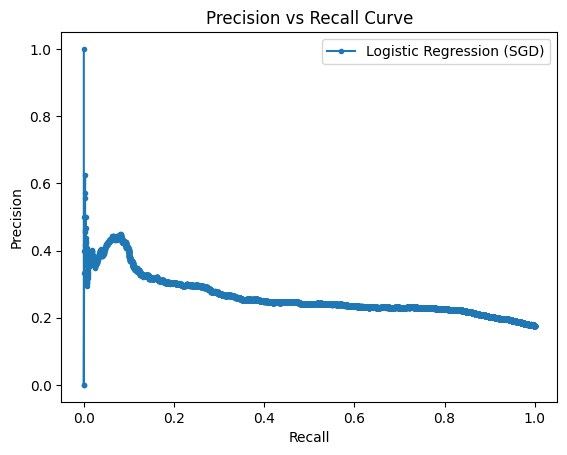

In [22]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# Convert X_test and y_test to tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

# After training, predict the probabilities for the entire dataset
with torch.no_grad():
    y_pred_proba = model(X_test_tensor.float()).numpy()  # Probabilities
    y_pred = (y_pred_proba >= 0.5).astype(int)  # Binary predictions

# Evaluate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
print(f'Final Training Precision: {final_precision}')
print(f'Final Training Recall: {final_recall}')

# Plot Precision-Recall curve
plt.plot(recall, precision, marker='.', label='Logistic Regression (SGD)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recall Curve')
plt.legend()
plt.show()


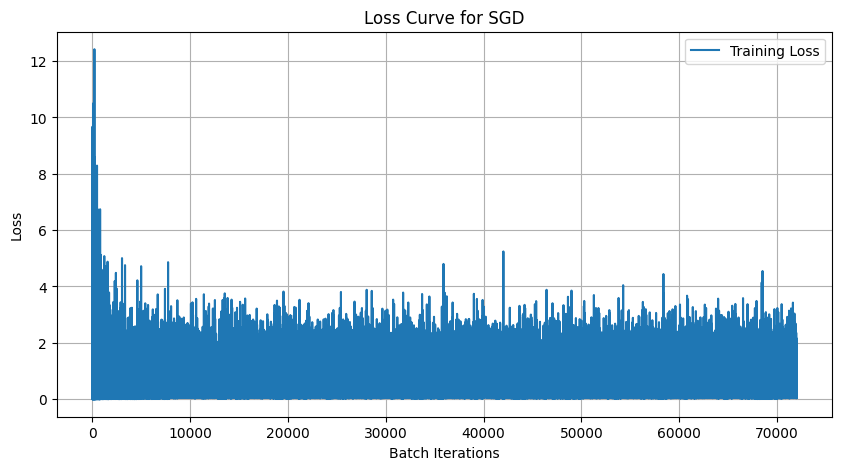

In [23]:

# Plotting the loss curve
plt.figure(figsize=(10, 5))
plt.plot(batch_loss, label='Training Loss')
plt.title('Loss Curve for SGD')
plt.xlabel('Batch Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()